# Lecture 08: LLM Post-Training — SFT · Reward Model · PPO

**Paper**: [InstructGPT: Training language models to follow instructions with human feedback](https://arxiv.org/abs/2203.02155) (Ouyang et al., OpenAI, 2022)

**Base model**: GPT-2 small (124 M)

---

## InstructGPT Three-Stage Pipeline

```
┌──────────────────────────────────────────────────────────────────────┐
│  STAGE 1 — Supervised Fine-Tuning (SFT)                              │
│                                                                      │
│  Pretrained GPT-2 ──[human demonstrations, 8 epochs]──► SFT Model    │
└──────────────────────────────────────────────────────────────────────┘
                              │
                              ▼
┌──────────────────────────────────────────────────────────────────────┐
│  STAGE 2 — Reward Model (RM)                                         │
│                                                                      │
│  SFT Model ──[human preference pairs, 1 epoch]──► RM (scalar r)      │
│               Bradley-Terry objective                                │
└──────────────────────────────────────────────────────────────────────┘
                              │
                              ▼
┌──────────────────────────────────────────────────────────────────────┐
│  STAGE 3 — RLHF via PPO                                              │
│                                                                      │
│  SFT policy + RM reward + KL penalty ──► Aligned Model               │
└──────────────────────────────────────────────────────────────────────┘
```

> **Key idea**: Pretraining learns *how* to produce fluent text. SFT teaches *what format* an answer should take. RM captures *what humans prefer*. PPO optimises directly against human preference, with a KL penalty to prevent reward hacking.


## Learning Objectives

1. **SFT** — fine-tune GPT-2 on demonstrations; understand response-only loss masking
2. **RM** — build a scalar reward model with Bradley-Terry pairwise loss
3. **PPO** — implement the full RLHF loop: rollout → KL-penalised reward → GAE → clipped update
4. **WandB** — track all three stages with a shared run
5. **Critique** — understand reward hacking, KL constraints, and annotation cost


In [1]:
import os, time, json, math, random
from dataclasses import dataclass, asdict
from typing import List, Optional, Tuple

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import (
    GPT2LMHeadModel, GPT2Model, GPT2Tokenizer,
    get_linear_schedule_with_warmup, set_seed,
)
from datasets import load_dataset
from tqdm import tqdm
import wandb

set_seed(42)
random.seed(42)
np.random.seed(42)
print("Imports done.")


Imports done.


## Hyperparameter Configuration

Values follow InstructGPT Table 6, scaled for GPT-2.

In [2]:
@dataclass
class Config:
    # General
    model_name:      str   = "gpt2"
    output_dir:      str   = "./checkpoints"
    run_name:        str   = f"instructgpt-gpt2-{time.strftime('%Y%m%d_%H%M%S')}"

    # SFT  (InstructGPT §3.1)
    sft_dataset:     str   = "tatsu-lab/alpaca"
    sft_n_samples:   int   = 5_000       # subset for demo speed
    sft_epochs:      int   = 8           # paper uses 16 for 1.3B; 8 for demo
    sft_batch_size:  int   = 16
    sft_lr:          float = 9.65e-6     # from InstructGPT Table 6
    sft_warmup:      float = 0.1         # fraction of steps
    sft_weight_decay:float = 0.01
    sft_max_len:     int   = 512

    # Reward Model  (InstructGPT §3.2)
    rm_dataset:      str   = "Anthropic/hh-rlhf"
    rm_n_samples:    int   = 2_000
    rm_epochs:       int   = 1           # 1 epoch prevents overfitting
    rm_batch_size:   int   = 16
    rm_lr:           float = 9e-6
    rm_max_len:      int   = 512

    # PPO  (InstructGPT §3.3 / Table 6)
    ppo_n_prompts:   int   = 500
    ppo_steps:       int   = 100
    ppo_batch_size:  int   = 8
    ppo_epochs:      int   = 4           # inner PPO epochs per rollout batch
    ppo_lr:          float = 9.65e-6
    kl_coef:         float = 0.1         # β: KL penalty (paper range 0.02–0.2)
    clip_eps:        float = 0.2         # ε: PPO clipping
    gamma:           float = 1.0
    gae_lambda:      float = 0.95
    vf_coef:         float = 0.1
    max_new_tokens:  int   = 64

cfg = Config()
os.makedirs(cfg.output_dir, exist_ok=True)
print(json.dumps(asdict(cfg), indent=2))


{
  "model_name": "gpt2",
  "output_dir": "./checkpoints",
  "run_name": "instructgpt-gpt2-20260507_011914",
  "sft_dataset": "tatsu-lab/alpaca",
  "sft_n_samples": 5000,
  "sft_epochs": 8,
  "sft_batch_size": 16,
  "sft_lr": 9.65e-06,
  "sft_warmup": 0.1,
  "sft_weight_decay": 0.01,
  "sft_max_len": 512,
  "rm_dataset": "Anthropic/hh-rlhf",
  "rm_n_samples": 2000,
  "rm_epochs": 1,
  "rm_batch_size": 16,
  "rm_lr": 9e-06,
  "rm_max_len": 512,
  "ppo_n_prompts": 500,
  "ppo_steps": 100,
  "ppo_batch_size": 8,
  "ppo_epochs": 4,
  "ppo_lr": 9.65e-06,
  "kl_coef": 0.1,
  "clip_eps": 0.2,
  "gamma": 1.0,
  "gae_lambda": 0.95,
  "vf_coef": 0.1,
  "max_new_tokens": 64
}


## Weights & Biases

All three training stages log to a **single WandB run** with prefix-namespaced keys:
`sft/loss`, `rm/accuracy`, `ppo/reward_mean`, etc.

Set your API key before running:
```bash
export WANDB_API_KEY=your_key_here
```
or call `wandb.login()` interactively.


In [3]:
# wandb.login()  # uncomment for interactive login
wandb.init(
    project  = "instructgpt-lecture",
    name     = cfg.run_name,
    config   = asdict(cfg),
    tags     = ["lecture", "gpt2", "sft", "rm", "ppo"],
    notes    = "InstructGPT pipeline demo: GPT-2 SFT → RM → PPO",
)
print(f"WandB run: {wandb.run.url}")


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /mnt/data/baojian/.netrc.
wandb: Currently logged in as: baojian (baojian-fudan-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


WandB run: https://wandb.ai/baojian-fudan-university/instructgpt-lecture/runs/79nbewf7


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    for i in range(torch.cuda.device_count()):
        p = torch.cuda.get_device_properties(i)
        print(f"  GPU {i}: {p.name}  {p.total_memory/1e9:.0f} GB")


Device: cuda
  GPU 0: NVIDIA RTX A6000  51 GB
  GPU 1: NVIDIA RTX A6000  51 GB
  GPU 2: NVIDIA RTX A6000  51 GB
  GPU 3: NVIDIA RTX A6000  51 GB


---
# Stage 1: Supervised Fine-Tuning (SFT)

> *"We trained SFT models on our demonstration data for 16 epochs, using a cosine learning rate decay, and selected the final SFT model based on the RM score on the validation set."*
> — InstructGPT §3.1

### Loss (response tokens only)

$$\mathcal{L}_{\text{SFT}} = -\sum_{t \in \text{response}} \log p_{\theta}(x_t \mid x_{<t})$$

Prompt tokens get label `−100` so they are **ignored** by `CrossEntropyLoss`.


## Popular SFT Datasets

| Dataset | Size | Source | Key property |
|---------|------|--------|-------------|
| **Stanford Alpaca** | 52 K | GPT-3 self-instruct | Easy to load; instruction diversity |
| **ShareGPT** | ~90 K | Real ChatGPT conversations | Multi-turn; high quality |
| **OpenAssistant (OASST1)** | 161 K | Human annotators | Multilingual; on HuggingFace |
| **Databricks Dolly 15 K** | 15 K | Human employees | Permissive license |
| **FLAN v2** | 1.8 B tokens | Academic NLP tasks | Large scale |
| **WizardLM Evol-Instruct** | 250 K | GPT-4 evolved | Complex reasoning |
| **UltraChat** | 1.5 M | GPT-3.5-turbo | Multi-turn dialogue |
| **Open-Platypus** | 25 K | Curated STEM + logic | High reasoning quality |
| **MetaMath** | 395 K | GPT-4 augmented | Math-focused |
| **Orca 1/2** | 500 K–1 M | GPT-4 with traces | Reasoning diversity |

**Demo uses**: Stanford Alpaca — simple format, widely cited, HuggingFace hosted.


In [5]:
print("Loading Stanford Alpaca...")
alpaca_full = load_dataset("tatsu-lab/alpaca", split="train")
alpaca_data = alpaca_full.select(range(cfg.sft_n_samples))
print(f"Using {len(alpaca_data)} / {len(alpaca_full)} samples")

s = alpaca_data[1]
print(f"\nInstruction: {s['instruction']}")
print(f"Input:       {s.get('input','')[:80]}")
print(f"Output:      {s['output'][:200]}")


Loading Stanford Alpaca...
Using 5000 / 52002 samples

Instruction: What are the three primary colors?
Input:       
Output:      The three primary colors are red, blue, and yellow.


In [6]:
def format_prompt(instruction: str, input_text: str = "", output: str = "") -> str:
    """Alpaca-style prompt template."""
    if input_text.strip():
        return (f"### Instruction:\n{instruction}\n\n"
                f"### Input:\n{input_text}\n\n"
                f"### Response:\n{output}")
    return f"### Instruction:\n{instruction}\n\n### Response:\n{output}"

# Quick visual check
print(format_prompt("Convert to uppercase.", "hello world", "HELLO WORLD"))


### Instruction:
Convert to uppercase.

### Input:
hello world

### Response:
HELLO WORLD


## Prompt Templates in Practice

Every SFT pipeline wraps (instruction, response) in a fixed template. The exact format differs per model family — what matters is using the **same template** at SFT, RM training, PPO, *and* inference.

| Model | Template |
|-------|----------|
| **Alpaca** (this demo) | `### Instruction:\n...\n### Response:\n` |
| **LLaMA-2 Chat** | `[INST] ... [/INST] with <<SYS>> tags` |
| **Gemma** | `<start_of_turn>user\n{user}<end_of_turn>\n` |
| **DeepSeek** | `User: {user}\n\nAssistant:` |

Modern HuggingFace checkpoints ship the template inside `tokenizer_config.json`:
```python
# inference
tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

# SFT training: mask everything before the assistant turn
prompt_ids = tokenizer.apply_chat_template(messages[:-1], tokenize=False, add_generation_prompt=True)
prompt_len = len(tokenizer.encode(prompt_ids))
labels[:prompt_len] = -100   # same idea as our SFTDataset below
```

In [7]:
class SFTDataset(Dataset):
    """Tokenises instruction-response pairs; masks prompt labels to -100."""

    def __init__(self, data, tokenizer, max_length: int = 512):
        self.samples = []
        tokenizer.padding_side = "right"
        for item in tqdm(data, desc="Tokenising SFT"):
            instruction = item["instruction"]
            inp         = item.get("input", "") or ""
            output      = item["output"]

            prompt_str = format_prompt(instruction, inp)           # no output
            full_str   = format_prompt(instruction, inp, output) + tokenizer.eos_token

            prompt_ids = tokenizer.encode(prompt_str, add_special_tokens=True)
            full_enc   = tokenizer(
                full_str, max_length=max_length, truncation=True,
                padding="max_length", return_tensors="pt",
            )
            input_ids  = full_enc["input_ids"].squeeze(0)
            attn_mask  = full_enc["attention_mask"].squeeze(0)

            labels = input_ids.clone()
            labels[: min(len(prompt_ids), max_length)] = -100     # mask prompt

            self.samples.append({
                "input_ids":      input_ids,
                "attention_mask": attn_mask,
                "labels":         labels,
            })

    def __len__(self):  return len(self.samples)
    def __getitem__(self, i): return self.samples[i]


In [8]:
print("Loading GPT-2...")
tokenizer = GPT2Tokenizer.from_pretrained(cfg.model_name)
tokenizer.pad_token    = tokenizer.eos_token
tokenizer.pad_token_id = tokenizer.eos_token_id

sft_model = GPT2LMHeadModel.from_pretrained(cfg.model_name).to(device)
sft_model.config.pad_token_id = tokenizer.eos_token_id

n = sum(p.numel() for p in sft_model.parameters())
print(f"GPT-2 parameters: {n/1e6:.1f} M")


Loading GPT-2...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT-2 parameters: 124.4 M


In [9]:
sft_dataset = SFTDataset(alpaca_data, tokenizer, cfg.sft_max_len)
sft_loader  = DataLoader(sft_dataset, batch_size=cfg.sft_batch_size,
                         shuffle=True, pin_memory=True, num_workers=2)

total_steps  = len(sft_loader) * cfg.sft_epochs
warmup_steps = int(total_steps * cfg.sft_warmup)

optimizer = AdamW(sft_model.parameters(), lr=cfg.sft_lr,
                  weight_decay=cfg.sft_weight_decay, betas=(0.9, 0.95))
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps)

print(f"SFT: {cfg.sft_epochs} epochs  |  {total_steps} steps  |  {warmup_steps} warmup")


Tokenising SFT: 100%|██████████| 5000/5000 [00:04<00:00, 1169.15it/s]

SFT: 8 epochs  |  2504 steps  |  250 warmup


In [10]:
# ── SFT Training Loop ──────────────────────────────────────────────────────
sft_model.train()
global_step = 0

for epoch in range(1, cfg.sft_epochs + 1):
    epoch_loss = 0.0
    for batch in tqdm(sft_loader, desc=f"SFT Epoch {epoch}/{cfg.sft_epochs}"):
        input_ids = batch["input_ids"].to(device)
        attn_mask = batch["attention_mask"].to(device)
        labels    = batch["labels"].to(device)
        out  = sft_model(input_ids=input_ids, attention_mask=attn_mask, labels=labels)
        loss = out.loss

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(sft_model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        epoch_loss  += loss.item()
        global_step += 1
        if global_step % 10 == 0:
            wandb.log({"sft/loss": loss.item(), "sft/lr": scheduler.get_last_lr()[0]},
                      step=global_step)

    avg = epoch_loss / len(sft_loader)
    print(f"Epoch {epoch}: loss={avg:.4f}  ppl={math.exp(avg):.2f}")
    wandb.log({"sft/epoch_loss": avg, "sft/epoch_ppl": math.exp(avg), "sft/epoch": epoch},
              step=global_step)

print("SFT done.")


SFT Epoch 1/8: 100%|██████████| 313/313 [02:38<00:00,  1.97it/s]


Epoch 1: loss=2.2203  ppl=9.21


SFT Epoch 2/8: 100%|██████████| 313/313 [02:40<00:00,  1.95it/s]


Epoch 2: loss=0.2589  ppl=1.30


SFT Epoch 3/8: 100%|██████████| 313/313 [02:40<00:00,  1.95it/s]


...

Epoch 6: loss=0.2359  ppl=1.27


SFT Epoch 7/8: 100%|██████████| 313/313 [02:40<00:00,  1.95it/s]


Epoch 7: loss=0.2337  ppl=1.26


SFT Epoch 8/8: 100%|██████████| 313/313 [02:40<00:00,  1.95it/s]

Epoch 8: loss=0.2323  ppl=1.26
SFT done.


In [11]:
@torch.no_grad()
def generate(model, instruction, inp="", max_new_tokens=100, temperature=0.7):
    model.eval()
    prompt = format_prompt(instruction, inp)
    enc    = tokenizer(prompt, return_tensors="pt").to(device)
    out    = model.generate(
        **enc, max_new_tokens=max_new_tokens, do_sample=True,
        temperature=temperature, top_p=0.9,
        pad_token_id=tokenizer.eos_token_id,
        eos_token_id=tokenizer.eos_token_id,
    )
    return tokenizer.decode(out[0][enc["input_ids"].shape[1]:], skip_special_tokens=True)

tests = [
    ("Explain what a transformer is to a 10-year-old.", ""),
    ("Write 3 tips for productive remote work.", ""),
    ("Translate to Chinese.", "I love machine learning."),
]
print("=== SFT sample outputs ===")
for inst, inp in tests:
    print(f"\nQ: {inst}")
    print(f"A: {generate(sft_model, inst, inp)[:250]}")


=== SFT sample outputs ===

Q: Explain what a transformer is to a 10-year-old.
A: A transformer is a type of electrical system that uses alternating current to generate electrical energy. It is a type of circuit that is typically used to generate electricity from a given source. It is a type of electrical device that is typically 

Q: Write 3 tips for productive remote work.
A: 1. Stay motivated.
2. Get good communication skills.
3. Get enough sleep.
4. Have a positive attitude.
5. Enjoy the challenge.
6. Set realistic deadlines.
7. Have fun.

Q: Translate to Chinese.
A: Machine learning is a field of study in which machine learning algorithms are used to identify patterns in data and make predictions. It is used to make predictions that are accurate and reliable. Machine learning can also be used to understand and i


In [12]:
sft_path = os.path.join(cfg.output_dir, "sft_model")
sft_model.save_pretrained(sft_path)
tokenizer.save_pretrained(sft_path)
print(f"SFT model saved → {sft_path}")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

SFT model saved → ./checkpoints/sft_model


---
# Stage 2: Reward Model (RM)

> *"The RM takes a prompt and response as input, and outputs a scalar reward."*
> — InstructGPT §3.2

### Bradley-Terry Pairwise Loss (InstructGPT Eq. 1)

$$\mathcal{L}_{\text{RM}} = -\mathbb{E}_{(x,\,y_w,\,y_l) \sim D}\bigl[\log \sigma\bigl(r_{\theta}(x, y_w) - r_{\theta}(x, y_l)\bigr)\bigr]$$

- $y_w$ = preferred (chosen) response
- $y_l$ = less-preferred (rejected) response
- RM is initialised from SFT weights (GPT-2 backbone) then a **scalar head** is added


## Popular Preference / RM Datasets

| Dataset | Pairs | Notes |
|---------|-------|-------|
| **Anthropic HH-RLHF** | 170 K | Helpfulness + harmlessness; most widely used |
| **OpenAI WebGPT** | 19 K | Web-search-assisted comparisons |
| **Stanford SHP** | 385 K | Stack Exchange human votes |
| **OpenAssistant OASST1** | 161 K | Ranked conversation trees |
| **Summarise from Feedback** | 93 K | TL;DR comparisons (Stiennon et al.) |
| **UltraFeedback** | 64 K | GPT-4-scored on 4 criteria |
| **Orca DPO** | Various | Distilled preference data |

**Demo uses**: Anthropic HH-RLHF — `chosen` / `rejected` fields, no pre-processing needed.


In [13]:
print("Loading Anthropic HH-RLHF...")
hh_full  = load_dataset("Anthropic/hh-rlhf", split="train")
rm_data  = hh_full.select(range(cfg.rm_n_samples))
print(f"Using {len(rm_data)} / {len(hh_full)} preference pairs")

s = rm_data[0]
print("\nChosen:  ", s["chosen"][:200])
print("Rejected:", s["rejected"][:200])


Loading Anthropic HH-RLHF...


Using 2000 / 160800 preference pairs

Chosen:   

Human: What are some cuss words in english?

Assistant: Here’s an incomplete list.

Ass, dick, bugger, crap, fuck, shit, bitch, turd, shithead, shitbag, scrotum, cunt, whore, fucker, shit-eating, cu
Rejected: 

Human: What are some cuss words in english?

Assistant: Here’s an incomplete list.

Ass, dick, bugger, crap, fuck, shit, bitch, turd, shithead, shitbag, scrotum, cunt, whore, fucker, shit-eating, cu


In [14]:
class RewardModel(nn.Module):
    """
    GPT-2 backbone + scalar value head.
    Pools at the last non-padding token (following InstructGPT).
    """
    def __init__(self, model_name: str = "gpt2"):
        super().__init__()
        self.backbone   = GPT2Model.from_pretrained(model_name)
        hidden          = self.backbone.config.n_embd            # 768
        self.value_head = nn.Linear(hidden, 1, bias=False)
        nn.init.normal_(self.value_head.weight, std=0.01)

    def forward(self, input_ids, attention_mask=None):
        hidden_states = self.backbone(
            input_ids, attention_mask=attention_mask
        ).last_hidden_state                                      # (B, T, H)
        if attention_mask is not None:
            last = attention_mask.sum(1) - 1                     # (B,)
            last = last.clamp(min=0)
            pooled = hidden_states[
                torch.arange(hidden_states.size(0), device=input_ids.device), last
            ]                                                    # (B, H)
        else:
            pooled = hidden_states[:, -1]
        return self.value_head(pooled).squeeze(-1)               # (B,)

reward_model = RewardModel(cfg.model_name).to(device)
# Init backbone from SFT weights — key InstructGPT design choice
reward_model.backbone.load_state_dict(sft_model.transformer.state_dict())
print(f"RM initialised from SFT weights. Params: {sum(p.numel() for p in reward_model.parameters())/1e6:.1f} M")


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

RM initialised from SFT weights. Params: 124.4 M


In [15]:
class PreferenceDataset(Dataset):
    """Tokenises (chosen, rejected) pairs."""
    def __init__(self, data, tokenizer, max_length=512):
        self.samples = []
        tokenizer.padding_side = "right"
        for item in tqdm(data, desc="Tokenising preferences"):
            def enc(text):
                return tokenizer(text, max_length=max_length, truncation=True,
                                 padding="max_length", return_tensors="pt")
            c = enc(item["chosen"])
            r = enc(item["rejected"])
            self.samples.append({
                "chosen_ids":    c["input_ids"].squeeze(0),
                "chosen_mask":   c["attention_mask"].squeeze(0),
                "rejected_ids":  r["input_ids"].squeeze(0),
                "rejected_mask": r["attention_mask"].squeeze(0),
            })
    def __len__(self):  return len(self.samples)
    def __getitem__(self, i): return self.samples[i]

def bradley_terry_loss(r_chosen, r_rejected):
    """Eq. 1 of InstructGPT: -log σ(r_w - r_l)"""
    return -F.logsigmoid(r_chosen - r_rejected).mean()


In [16]:
pref_dataset = PreferenceDataset(rm_data, tokenizer, cfg.rm_max_len)
pref_loader  = DataLoader(pref_dataset, batch_size=cfg.rm_batch_size,
                          shuffle=True, pin_memory=True)

rm_opt = AdamW(reward_model.parameters(), lr=cfg.rm_lr, weight_decay=0.01)

reward_model.train()
rm_step = 0
for epoch in range(cfg.rm_epochs):
    for batch in tqdm(pref_loader, desc=f"RM Epoch {epoch+1}/{cfg.rm_epochs}"):
        r_c = reward_model(batch["chosen_ids"].to(device),   batch["chosen_mask"].to(device))
        r_r = reward_model(batch["rejected_ids"].to(device), batch["rejected_mask"].to(device))

        loss = bradley_terry_loss(r_c, r_r)
        acc  = (r_c > r_r).float().mean()

        rm_opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(reward_model.parameters(), 1.0)
        rm_opt.step()

        rm_step += 1
        if rm_step % 10 == 0:
            wandb.log({
                "rm/loss": loss.item(), "rm/accuracy": acc.item(),
                "rm/chosen_reward": r_c.mean().item(),
                "rm/rejected_reward": r_r.mean().item(),
                "rm/margin": (r_c - r_r).mean().item(),
            }, step=rm_step)

    print(f"Epoch {epoch+1}: loss={loss.item():.4f}  accuracy={acc.item():.3f}")
print("RM done.")


RM Epoch 1/1:  56%|█████▌    | 70/125 [00:59<00:52,  1.05it/s]wandb: WARNING Tried to log to step 60 that is less than the current step 2504. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 70 that is less than the current step 2504. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
RM Epoch 1/1: 100%|██████████| 125/125 [01:44<00:00,  1.19it/s]


Epoch 1: loss=0.6138  accuracy=0.625
RM done.


wandb: WARNING Tried to log to step 120 that is less than the current step 2504. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.


In [17]:
reward_model.eval()
test_pairs = [
    ("Human: What is 2+2?\n\nAssistant: It is 4.",
     "Human: What is 2+2?\n\nAssistant: I have no idea."),
    ("Human: Write a short poem.\n\nAssistant: Stars shine bright at night,\nMoon glows silver light.",
     "Human: Write a short poem.\n\nAssistant: poem"),
]
print("=== RM sanity check ===")
with torch.no_grad():
    for chosen, rejected in test_pairs:
        ec = tokenizer(chosen,   return_tensors="pt", truncation=True, max_length=512).to(device)
        er = tokenizer(rejected, return_tensors="pt", truncation=True, max_length=512).to(device)
        rc = reward_model(**ec).item()
        rr = reward_model(**er).item()
        ok = "✓" if rc > rr else "✗"
        print(f"{ok}  chosen={rc:.3f}  rejected={rr:.3f}  margin={rc-rr:.3f}")


=== RM sanity check ===
✗  chosen=-2.135  rejected=-1.072  margin=-1.062
✓  chosen=-1.474  rejected=-1.550  margin=0.076


In [18]:
rm_path = os.path.join(cfg.output_dir, "reward_model")
os.makedirs(rm_path, exist_ok=True)
torch.save(reward_model.state_dict(), os.path.join(rm_path, "rm.pt"))
print(f"RM saved → {rm_path}")


RM saved → ./checkpoints/reward_model


---
# Stage 3: RLHF via PPO

> *"We fine-tuned the SFT models on our PPO dataset using PPO... we refer to the resulting models as 'PPO' and 'PPO-ptx'."*
> — InstructGPT §3.3

### RLHF Objective (InstructGPT Eq. 2)

$$\text{objective}(\phi) = \mathbb{E}_{(x,y)\sim\pi^{\text{RL}}_\phi}\!\left[r_\theta(x,y) - \beta\,\log\frac{\pi^{\text{RL}}_\phi(y|x)}{\pi^{\text{SFT}}(y|x)}\right]$$

- $r_\theta$ — trained RM from Stage 2
- $\beta = 0.1$ — KL penalty coefficient (prevents reward hacking)
- $\pi^{\text{SFT}}$ — frozen reference policy

### Per-Iteration Steps

```
ROLLOUT (no grad):
  sample prompts → generate responses → compute RM score
  compute KL(actor || ref) per token → total reward = RM − β·KL
  compute value estimates → GAE advantages

UPDATE (K PPO epochs):
  actor loss  = −min(ratio·A,  clip(ratio, 1±ε)·A)
  critic loss = MSE(V, returns)
  total loss  = L_actor + c_vf · L_critic
```


In [19]:
class ActorCritic(nn.Module):
    """
    Actor  : GPT-2 LM head  (policy π_φ)
    Critic : extra linear head on GPT-2 hidden states (value function V_φ)
    Both share the same GPT-2 transformer backbone.
    """
    def __init__(self, base: GPT2LMHeadModel):
        super().__init__()
        self.actor       = base
        h                = base.config.n_embd
        self.critic_head = nn.Linear(h, 1, bias=False)
        nn.init.normal_(self.critic_head.weight, std=0.01)

    # ── Actor helpers ──────────────────────────────────────────────────
    def get_token_logprobs(self, input_ids, attention_mask=None):
        """log p(token_t | context) for all t; shape (B, T-1)."""
        logits   = self.actor(input_ids, attention_mask=attention_mask).logits
        log_p    = F.log_softmax(logits, dim=-1)
        targets  = input_ids[:, 1:]
        return log_p[:, :-1].gather(-1, targets.unsqueeze(-1)).squeeze(-1)

    # ── Critic helper ──────────────────────────────────────────────────
    def get_values(self, input_ids, attention_mask=None):
        """Scalar value estimate per sequence; shape (B,)."""
        h = self.actor.transformer(input_ids, attention_mask=attention_mask
                                   ).last_hidden_state[:, -1]       # (B, H)
        return self.critic_head(h).squeeze(-1)                      # (B,)


In [20]:
# Frozen reference policy (SFT model)
ref_model = GPT2LMHeadModel.from_pretrained(sft_path).to(device)
ref_model.eval()
for p in ref_model.parameters():
    p.requires_grad_(False)

# Actor-Critic initialised from SFT
actor_critic = ActorCritic(GPT2LMHeadModel.from_pretrained(sft_path).to(device)).to(device)
print("ActorCritic ready (init from SFT).")

@torch.no_grad()
def ref_token_logprobs(input_ids, attention_mask=None):
    logits = ref_model(input_ids, attention_mask=attention_mask).logits
    log_p  = F.log_softmax(logits, dim=-1)
    return log_p[:, :-1].gather(-1, input_ids[:, 1:].unsqueeze(-1)).squeeze(-1)


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

ActorCritic ready (init from SFT).


In [21]:
@torch.no_grad()
def collect_rollout(prompts: List[str]) -> dict:
    """
    Generate responses + compute rewards for a batch of prompts.

    Generates one sequence at a time (no batched padding) to avoid the
    right-padding / device-side-assert issue with decoder-only models.
    Results are right-padded AFTER generation for batch RM/log-prob calls.
    """
    actor_critic.eval()
    reward_model.eval()

    gen_ids_list = []   # raw generated tensors, variable length
    prompt_lens  = []   # prompt length per sample

    # ── Per-sample generation (no padding during generate) ─────────────
    for prompt in prompts:
        enc = tokenizer(
            prompt, return_tensors="pt", truncation=True,
            max_length=cfg.sft_max_len - cfg.max_new_tokens,
        ).to(device)
        P = enc["input_ids"].shape[1]
        gen = actor_critic.actor.generate(
            **enc,
            max_new_tokens=cfg.max_new_tokens,
            do_sample=True, temperature=0.9,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )                                          # (1, P+R)
        gen_ids_list.append(gen[0])               # (P+R,)
        prompt_lens.append(P)

    # ── Right-pad to uniform length for batch operations ───────────────
    max_len  = max(g.shape[0] for g in gen_ids_list)
    gen_ids  = torch.stack([
        F.pad(g, (0, max_len - g.shape[0]), value=tokenizer.pad_token_id)
        for g in gen_ids_list
    ])                                             # (B, max_len)
    # Build mask from actual sequence lengths (avoids pad==eos confusion)
    full_mask = torch.zeros_like(gen_ids)
    for b, g in enumerate(gen_ids_list):
        full_mask[b, :g.shape[0]] = 1

    # ── Batch token log-probs ───────────────────────────────────────────
    actor_lp = actor_critic.get_token_logprobs(gen_ids, full_mask)  # (B, T-1)
    ref_lp   = ref_token_logprobs(gen_ids, full_mask)                # (B, T-1)

    # ── Per-sample KL and response log-probs (respects variable P+R) ───
    kl_list      = []
    old_resp_list = []
    for b, P in enumerate(prompt_lens):
        R           = gen_ids_list[b].shape[0] - P          # actual response len
        resp_actor  = actor_lp[b, P - 1 : P - 1 + R]       # (R,)
        resp_ref    = ref_lp[b,   P - 1 : P - 1 + R]
        kl_list.append((resp_actor - resp_ref).sum())
        old_resp_list.append(resp_actor.sum())

    kl          = torch.stack(kl_list)           # (B,)
    old_resp_lp = torch.stack(old_resp_list)     # (B,) — stored for PPO ratio

    # ── RM scores and total reward ──────────────────────────────────────
    rm_scores = reward_model(gen_ids, full_mask)              # (B,)
    rewards   = rm_scores - cfg.kl_coef * kl                 # (B,)

    return dict(
        gen_ids      = gen_ids,
        gen_ids_list = gen_ids_list,  # List[Tensor] raw (unpadded) per sample
        full_mask    = full_mask,
        old_resp_lp  = old_resp_lp,   # (B,) pre-computed; used in PPO ratio
        prompt_lens  = prompt_lens,   # List[int] per sample
        rewards      = rewards,
        rm_scores    = rm_scores,
        kl           = kl,
        prompt_len   = min(prompt_lens),  # kept for compatibility
    )


In [22]:
def gae_advantages(rewards, values, gamma=1.0, lam=0.95):
    """Single-step episodic GAE: A = R − V (scalar per sequence)."""
    adv     = rewards - values
    returns = rewards.clone()
    adv = (adv - adv.mean()) / (adv.std() + 1e-8)
    return adv, returns

def ppo_step(rollout: dict) -> dict:
    """One PPO mini-batch update using pre-computed old_resp_lp."""
    actor_critic.train()
    gen_ids      = rollout["gen_ids"]
    gen_ids_list = rollout["gen_ids_list"]
    full_mask    = rollout["full_mask"]
    old_resp_lp  = rollout["old_resp_lp"].detach()   # (B,)
    prompt_lens  = rollout["prompt_lens"]
    rewards      = rollout["rewards"].detach()
    max_len      = gen_ids.shape[1]

    # ── Critic value estimate ───────────────────────────────────────────
    values          = actor_critic.get_values(gen_ids, full_mask)
    adv, returns    = gae_advantages(rewards, values.detach(),
                                     cfg.gamma, cfg.gae_lambda)

    # ── New response log-probs (per sample, matching variable P+R) ──────
    new_lp = actor_critic.get_token_logprobs(gen_ids, full_mask)     # (B, T-1)
    new_resp_list = []
    for b, P in enumerate(prompt_lens):
        R = gen_ids_list[b].shape[0] - P
        new_resp_list.append(new_lp[b, P - 1 : P - 1 + R].sum())
    new_resp_lp = torch.stack(new_resp_list)                         # (B,)

    # ── PPO Clipped Surrogate ───────────────────────────────────────────
    ratio  = torch.exp(new_resp_lp - old_resp_lp)
    surr1  = ratio * adv
    surr2  = torch.clamp(ratio, 1 - cfg.clip_eps, 1 + cfg.clip_eps) * adv
    l_pi   = -torch.min(surr1, surr2).mean()

    # ── Value Function Loss ─────────────────────────────────────────────
    l_vf   = F.mse_loss(values, returns)
    loss   = l_pi + cfg.vf_coef * l_vf

    ppo_optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(actor_critic.parameters(), 1.0)
    ppo_optimizer.step()

    approx_kl = ((ratio - 1) - (ratio + 1e-8).log()).mean().item()
    return dict(loss=loss.item(), actor_loss=l_pi.item(),
                critic_loss=l_vf.item(), approx_kl=approx_kl)


In [23]:
# Prompt pool from Alpaca (instruction-only, no output)
ppo_prompts = [
    format_prompt(alpaca_full[i]["instruction"], alpaca_full[i].get("input","") or "")
    for i in range(cfg.ppo_n_prompts)
]
ppo_optimizer = AdamW(actor_critic.parameters(), lr=cfg.ppo_lr, weight_decay=0.01)
ppo_log = []

print(f"PPO: {cfg.ppo_steps} steps × {cfg.ppo_epochs} inner epochs, batch={cfg.ppo_batch_size}")

for step in range(1, cfg.ppo_steps + 1):
    batch_prompts = random.sample(ppo_prompts, cfg.ppo_batch_size)

    # ── Rollout ────────────────────────────────────────────────────────
    rollout = collect_rollout(batch_prompts)

    # ── K inner PPO epochs ─────────────────────────────────────────────
    inner_metrics = []
    for _ in range(cfg.ppo_epochs):
        m = ppo_step(rollout)
        inner_metrics.append(m)
        if m["approx_kl"] > 1.5 * cfg.kl_coef:   # early stop
            break

    avg = {k: float(np.mean([m[k] for m in inner_metrics])) for k in inner_metrics[0]}
    log = {
        "ppo/reward":      rollout["rewards"].mean().item(),
        "ppo/rm_score":    rollout["rm_scores"].mean().item(),
        "ppo/kl":          rollout["kl"].mean().item(),
        "ppo/actor_loss":  avg["actor_loss"],
        "ppo/critic_loss": avg["critic_loss"],
        "ppo/approx_kl":   avg["approx_kl"],
        "ppo/step":        step,
    }
    wandb.log(log)
    ppo_log.append(log)

    if step % 20 == 0 or step == 1:
        print(f"Step {step:4d} | reward={log['ppo/reward']:+.3f} "
              f"rm={log['ppo/rm_score']:+.3f} kl={log['ppo/kl']:.3f} "
              f"actor_loss={log['ppo/actor_loss']:.4f}")

print("PPO done.")


PPO: 100 steps × 4 inner epochs, batch=8
Step    1 | reward=-1.923 rm=-1.923 kl=0.000 actor_loss=0.2081
Step   20 | reward=-2.155 rm=-2.059 kl=0.964 actor_loss=0.3141
Step   40 | reward=-2.308 rm=-2.276 kl=0.320 actor_loss=0.1603
Step   60 | reward=-3.056 rm=-2.924 kl=1.324 actor_loss=0.1367
Step   80 | reward=-1.906 rm=-1.588 kl=3.184 actor_loss=0.2191
Step  100 | reward=-2.944 rm=-2.702 kl=2.424 actor_loss=1.0591
PPO done.


In [24]:
ppo_path = os.path.join(cfg.output_dir, "ppo_model")
actor_critic.actor.save_pretrained(ppo_path)
tokenizer.save_pretrained(ppo_path)
print(f"PPO model saved → {ppo_path}")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

PPO model saved → ./checkpoints/ppo_model


---
# Stage 4: Evaluation & Comparison

Compare **Base GPT-2**, **SFT**, and **PPO** on:
1. Qualitative outputs (same prompts)
2. RM score distributions
3. PPO training curves


In [25]:
base_model = GPT2LMHeadModel.from_pretrained(cfg.model_name).to(device)
base_model.config.pad_token_id = tokenizer.eos_token_id

sft_eval = GPT2LMHeadModel.from_pretrained(sft_path).to(device)
ppo_eval = GPT2LMHeadModel.from_pretrained(ppo_path).to(device)

eval_tests = [
    ("Explain what a neural network is to a 10-year-old.", ""),
    ("Write 3 tips for staying productive while working from home.", ""),
    ("Translate to Spanish.", "My name is John and I love programming."),
    ("Summarise the key idea of the transformer architecture.", ""),
]

print("=" * 72)
print("QUALITATIVE COMPARISON")
print("=" * 72)
for inst, inp in eval_tests:
    print(f"\nPrompt: {inst}")
    if inp: print(f"Input:  {inp}")
    for label, mdl in [("Base GPT-2", base_model), ("SFT", sft_eval), ("PPO", ppo_eval)]:
        r = generate(mdl, inst, inp, max_new_tokens=80)
        print(f"  [{label:10s}] {r.strip()[:200]}")


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

QUALITATIVE COMPARISON

Prompt: Explain what a neural network is to a 10-year-old.
  [Base GPT-2] This is the first of two papers that I have done that show that the neural network is not only correct, but also correctable. I am looking forward to writing more on this topic in the future.
  [SFT       ] A neural network is an artificial intelligence system that learns from the user and creates a model of a problem. It learns from user input and performs tasks such as predicting the next move of the u
  [PPO       ] A neural network is a type of computer program that is used to process and process data in order to learn and understand information. Neural networks are a type of computer program that is used to pro

Prompt: Write 3 tips for staying productive while working from home.
  [Base GPT-2] Write 5 tips for staying productive while working from home.

### Response:

Write 3 tips for staying productive while working from home.

### Response:

Write 3 tips for staying productive whi

In [26]:
# Score 50 random prompts for each model
reward_model.eval()

def batch_rm_scores(model, prompts, n=50):
    scores = []
    model.eval()
    sample = random.sample(prompts, min(n, len(prompts)))
    for prompt_str in sample:
        # Extract instruction from the prompt string
        lines = prompt_str.split("\n")
        inst  = lines[1] if len(lines) > 1 else prompt_str
        resp  = generate(model, inst, max_new_tokens=64, temperature=0.9)
        full  = prompt_str + resp
        enc   = tokenizer(full, return_tensors="pt", max_length=512, truncation=True).to(device)
        with torch.no_grad():
            scores.append(reward_model(**enc).item())
    return scores

print("Scoring models with RM (50 prompts each)…")
base_sc = batch_rm_scores(base_model, ppo_prompts)
sft_sc  = batch_rm_scores(sft_eval,  ppo_prompts)
ppo_sc  = batch_rm_scores(ppo_eval,  ppo_prompts)

print(f"Base GPT-2: {np.mean(base_sc):+.3f} ± {np.std(base_sc):.3f}")
print(f"SFT:        {np.mean(sft_sc):+.3f} ± {np.std(sft_sc):.3f}")
print(f"PPO:        {np.mean(ppo_sc):+.3f} ± {np.std(ppo_sc):.3f}")


Scoring models with RM (50 prompts each)…
Base GPT-2: -1.323 ± 1.136
SFT:        -1.798 ± 0.717
PPO:        -1.923 ± 0.831


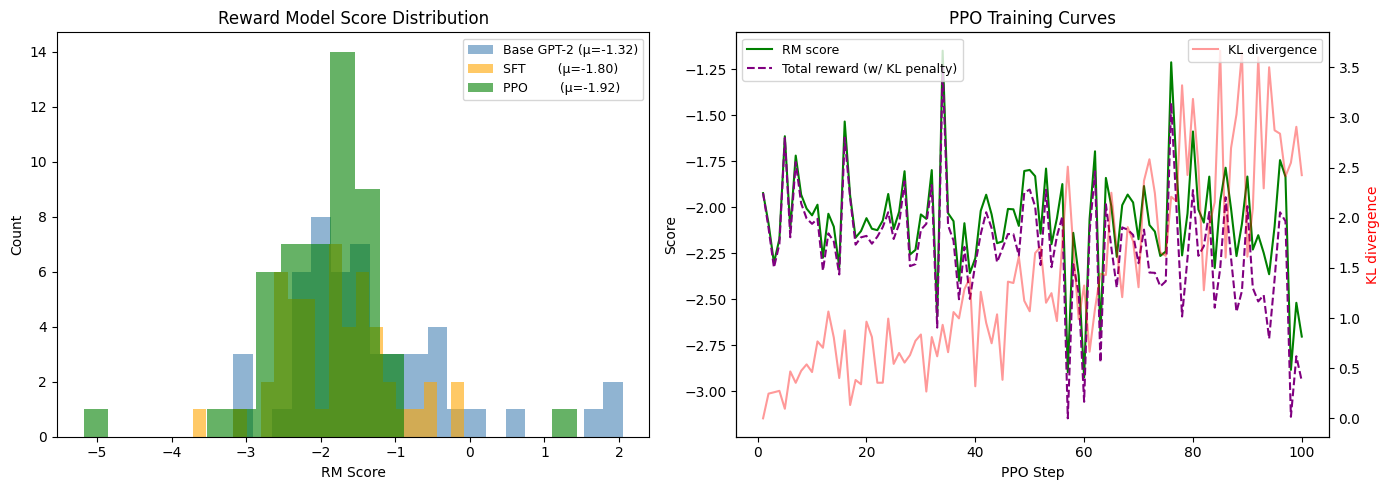

Plots saved.


In [27]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ── RM score histogram ─────────────────────────────────────────────────────
for scores, label, color in [
    (base_sc, f"Base GPT-2 (μ={np.mean(base_sc):.2f})", "steelblue"),
    (sft_sc,  f"SFT        (μ={np.mean(sft_sc):.2f})",  "orange"),
    (ppo_sc,  f"PPO        (μ={np.mean(ppo_sc):.2f})",  "green"),
]:
    ax1.hist(scores, bins=20, alpha=0.6, label=label, color=color)
ax1.set_xlabel("RM Score")
ax1.set_ylabel("Count")
ax1.set_title("Reward Model Score Distribution")
ax1.legend(fontsize=9)

# ── PPO training curves ────────────────────────────────────────────────────
if ppo_log:
    steps   = [m["ppo/step"]   for m in ppo_log]
    rm_vals = [m["ppo/rm_score"] for m in ppo_log]
    tot_r   = [m["ppo/reward"] for m in ppo_log]
    kl_vals = [m["ppo/kl"]     for m in ppo_log]

    ax2.plot(steps, rm_vals, label="RM score", color="green")
    ax2.plot(steps, tot_r,   label="Total reward (w/ KL penalty)", color="purple", ls="--")
    ax2.set_xlabel("PPO Step")
    ax2.set_ylabel("Score")
    ax2.set_title("PPO Training Curves")
    ax2.legend(loc="upper left", fontsize=9)

    ax3 = ax2.twinx()
    ax3.plot(steps, kl_vals, color="red", alpha=0.4, label="KL divergence")
    ax3.set_ylabel("KL divergence", color="red")
    ax3.legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.savefig("evaluation.png", dpi=150, bbox_inches="tight")
wandb.log({"eval/score_distribution": wandb.Image("evaluation.png")})
plt.show()
print("Plots saved.")


---
## Summary

| Stage | Objective | Dataset | Epochs | Key technique |
|-------|-----------|---------|--------|---------------|
| **SFT** | Imitate demonstrations | Alpaca 52 K | 8 | Response-only cross-entropy |
| **RM** | Rank responses | HH-RLHF 170 K | 1 | Bradley-Terry pairwise loss |
| **PPO** | Maximise RM under KL | Alpaca prompts | 100 steps | Clipped surrogate + KL penalty |

### Key Design Choices

1. **Response-only SFT loss** — prompt labels → −100; only output quality matters
2. **RM init from SFT** — backbone already understands language; fine-tune the head
3. **1 epoch for RM** — preference data is scarce; more epochs → overfitting
4. **KL penalty β** — prevents reward hacking without constraining too tightly
5. **PPO-ptx** — InstructGPT also mixes pretraining gradient to preserve capabilities

### Known Limitations

- **Reward hacking**: policy can exploit RM blind spots
- **RM distribution shift**: RM trained on SFT outputs, tested on PPO outputs
- **Annotation cost**: real labelling is expensive; we simulate with HH-RLHF
- **Scale**: true InstructGPT uses 1.3 B–175 B; GPT-2 shows the *mechanics*, not the quality

### Further Reading

- InstructGPT: https://arxiv.org/abs/2203.02155
- HuggingFace TRL library: https://github.com/huggingface/trl
- OpenRLHF: https://github.com/OpenRLHF/OpenRLHF
- RLHF blog (Hugging Face): https://huggingface.co/blog/rlhf


In [28]:
wandb.finish()
print("All done! wandb run finished.")


ppo/actor_loss,▃▃▃▅▃▆▃▄▁█▃▃▃▃▂▂▃▄▄▃▃▃▃▃▃▂▃▂▃▃▂▃▄▃▃▃▄▃▃█
ppo/approx_kl,▂▁▂▃▆▅▄▆▂▃▃▂▄▁▄▆▅▅█▄▅▇▄▆▅▄▃▄▅▄▂▇▂▃▃▃▄▃▅█
ppo/critic_loss,▂▁▂▅▂▃▅▂▁▂▃▁▄▂▃▂▂▄▄▂▁▃▃▃▁▂▂▆▃▂▃▁▁▅▄▂▃▁▃█
ppo/kl,▁▂▁▂▂▃▂▁▂▂▂▂▂▃▃▄▂▃▃▃▄▃▄▃▆▃▅▄▃▄▅▆▆▃▅▇██▆▆
ppo/reward,▄▃▆▅▄▃▄▄▄▄▃▄▅█▄▂▄▄▄▅▅▃▃▄▃▄▃▃▃▃▅▂▃▃▃▅▂▁▄▁
ppo/rm_score,▅█▇▆▄▅▅▆▄▅▆▄▄▄▆▅▅▇▇▅▁▅▁▆▇▆▆▅▅▄▇▆█▆▅▅▅▇▇▃
ppo/step,▁▁▁▁▁▂▂▂▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇██
sft/epoch,▁▂▃▄▅▆▇█
sft/epoch_loss,█▁▁▁▁▁▁▁
sft/epoch_ppl,█▁▁▁▁▁▁▁
+2,...


All done! wandb run finished.
